# Линейная регрессия на California Housing

Разбираем базовый рабочий процесс: задаём базовую метрику, обучаем линейную регрессию и интерпретируем результаты.


## Импорт библиотек

Подготовим инструменты для загрузки данных, обучения и оценки модели.


In [38]:
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.dummy import DummyRegressor
import matplotlib.pyplot as plt

RANDOM_STATE = 42


## Загрузка и разбиение датасета

Используем California Housing: признаки описывают характеристики районов Калифорнии, а целевая переменная — медианную стоимость жилья.


In [39]:
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((16512, 8), (4128, 8), (16512,), (4128,))

## Первичный осмотр признаков

Посмотрим на сводные статистики по числовым признакам обучающей выборки, чтобы понять масштабы и разброс.


In [40]:
feature_summary = (
    X_train.describe()
    .T[['mean', 'std', 'min', 'max']]
    .rename(columns={"mean": "Mean", "std": "Std", "min": "Min", "max": "Max"})
    .round(2)
)
feature_summary


,Mean,Std,Min,Max
MedInc,3.88,1.90,0.50,15.00
HouseAge,28.61,12.60,1.00,52.00
AveRooms,5.44,2.39,0.89,141.91
AveBedrms,1.10,0.43,0.33,25.64
Population,1426.45,1137.06,3.00,35682.00
AveOccup,3.10,11.58,0.69,1243.33
Latitude,35.64,2.14,32.55,41.95
Longitude,-119.58,2.01,-124.35,-114.31


Статистики показывают, что признаки измеряются в разных шкалах: от долей (например, `AveOccup`) до сотен (`Population`). Это объясняет необходимость стандартизации перед интерпретацией коэффициентов.


In [41]:
correlation = X_train.corrwith(y_train).sort_values(ascending=False)
correlation


MedInc        0.690647
AveRooms      0.158485
HouseAge      0.103706
AveOccup     -0.022030
Population   -0.026032
Longitude    -0.046349
AveBedrms    -0.051351
Latitude     -0.142983
dtype: float64

Корреляции с целевой переменной указывают, какие признаки сильнее всего связаны с ценой: например, медианный доход (`MedInc`) имеет наибольшую положительную связь.


## Распределение целевой переменной

Изучим числовые характеристики и форму распределения целевой переменной `MedHouseVal`.


In [42]:
y_train.describe().round(2)


count    16512.00
mean         2.07
std          1.16
min          0.15
25%          1.20
50%          1.80
75%          2.65
max          5.00
Name: MedHouseVal, dtype: float64

Средняя медианная стоимость жилья около 2.07 (в условных сотнях тысяч долларов), при этом максимум достигает 5.00, что говорит о правостороннем распределении.


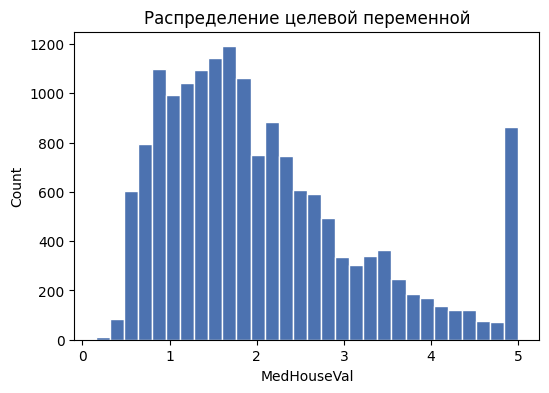

In [43]:
plt.figure(figsize=(6, 4))
plt.hist(y_train, bins=30, color="#4C72B0", edgecolor="white")
plt.xlabel("MedHouseVal")
plt.ylabel("Count")
plt.title("Распределение целевой переменной")
plt.show()


Гистограмма подтверждает наличие длинного хвоста: редкие, но дорогие районы сильно отличаются от основной массы наблюдений.


## Почему MAE и R²

MAE удобно интерпретировать в тех же единицах, что и целевая переменная: он показывает, на сколько сотен тысяч долларов в среднем ошибается модель, что особенно важно при асимметричном распределении. Метрика R² показывает долю объяснённой дисперсии и позволяет сравнивать модель с константным предсказателем: если R² положителен, мы знаем, что модель полезнее базовой медианы.


## Базовый уровень качества

В качестве бенчмарка используем `DummyRegressor`, который всегда предсказывает медиану. Это помогает понять, есть ли смысл строить более сложную модель.


In [44]:
dummy = DummyRegressor(strategy="median")
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
r2_dummy = r2_score(y_test, y_pred_dummy)
mae_dummy, r2_dummy


(0.8740399224806202, -0.050208628996205595)

## Линейная регрессия с масштабированием

Перед обучением стандартизируем признаки, чтобы коэффициенты модели были сопоставимы по масштабу.


In [45]:
linreg = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ]
)
linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae, r2


(0.5332001304956565, 0.5757877060324511)

In [46]:
metrics = pd.DataFrame(
    {
        "Model": ["Baseline (median)", "Linear regression"],
        "MAE": [mae_dummy, mae],
        "R^2": [r2_dummy, r2],
    }
).set_index("Model")
metrics


,MAE,R^2
Model,,
Baseline (median),0.87404,-0.050209
Linear regression,0.53320,0.575788


Линейная регрессия заметно снижает MAE и даёт положительный `R^2`, тогда как базовая модель возвращает отрицательное значение. Значит, линейная регрессия действительно учится извлекать закономерности из признаков.


## Интерпретация коэффициентов

Берём коэффициенты обученной модели после стандартизации признаков. Теперь их величины можно сравнивать между собой.


In [47]:
coef = linreg.named_steps["model"].coef_
coef_df = (
    pd.DataFrame({"feature": X.columns, "coefficient": coef})
    .sort_values("coefficient", ascending=False)
    .reset_index(drop=True)
)
coef_df


,feature,coefficient
0,MedInc,0.854383
1,AveBedrms,0.339259
2,HouseAge,0.122546
3,Population,-0.002308
4,AveOccup,-0.040829
5,AveRooms,-0.294410
6,Longitude,-0.869842
7,Latitude,-0.896929


Положительные коэффициенты повышают предсказанную стоимость жилья, отрицательные — снижают. Масштаб показывает относительную силу влияния при фиксированных остальных признаках.


## Диагностика предсказаний

Проверим, насколько хорошо модель совпадает с истинными значениями, построив диаграмму рассеяния.


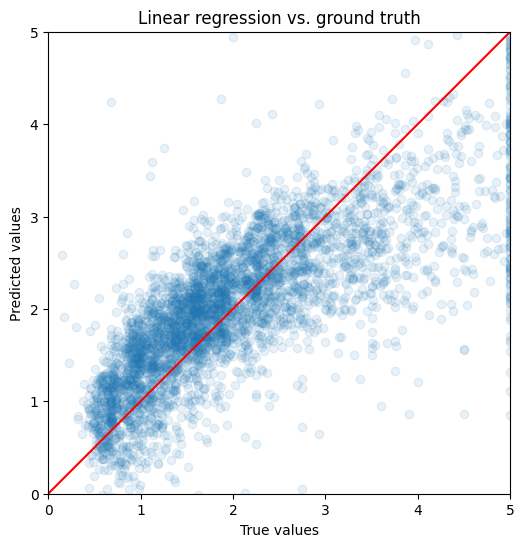

In [48]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.1)
plt.xlabel("True values")
plt.ylabel("Predicted values")
plt.axis("equal")
plt.axis("square")
lims = [0, 5]
plt.xlim(lims)
plt.ylim(lims)
plt.plot(lims, lims, color="red")
plt.title("Linear regression vs. ground truth")
plt.show()


Точки плотно располагаются вдоль диагонали, но заметно рассеяны при высоких значениях цены. Это сигнал, что линейная модель не улавливает всю нелинейность данных — хороший повод попробовать более сложные алгоритмы.
